In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('src')
import mineralML as mm
import pandas as pd
pd.set_option('display.max_columns', None)

In [4]:
mm.__version__

'0.0.3.2'

In [5]:
#!pip install --upgrade mineralML

In [28]:

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.labelsize': 14,
    'pdf.fonttype': 42,
    'font.family': 'Avenir',
    'font.size': 14,
    'xtick.direction': 'in',  # Set x-tick direction to 'in'
    'ytick.direction': 'in',  # Set y-tick direction to 'in'
    'xtick.major.size': 5,    # Set x-tick length
    'ytick.major.size': 5,    # Set y-tick length
    'xtick.major.pad': 6.5,   # Set x-tick padding
    'ytick.major.pad': 6.5    # Set y-tick padding
})


In [ ]:
# GEOROC data 
df=pd.read_csv('Validation_Data/GEOROC_validationdata_Fe_2025.csv')
min_df = mm.prep_df_nn(df)
GEOROC, min_probability_matrix = mm.predict_class_prob_nnwr(min_df)

# GEOROC = pd.read_pickle("min_df_pred300.pkl")
## Test dataframe

/var/folders/k_/fnnxsv2n52qb5r1hq85f3p2c0000gn/T/ipykernel_17012/1745924586.py:3: UserWarning: Some non-numeric values were found in the oxides columns and have been coerced to NaN.
  min_df = mm.prep_df_nn(df)
/Users/sarahshi/Documents/GitHub/mineralML/src/mineralML/hybrid.py:1818: RuntimeWarning: invalid value encountered in sqrt
  std_matrix = np.sqrt(probs_var.detach().cpu().numpy())


FileNotFoundError: [Errno 2] No such file or directory: 'min_df_v3_natural.csv'

In [13]:
GEOROC['Citation']=df['CITATION']
GEOROC['SAMPLE NAME']=df['SAMPLE NAME']

In [17]:
Test = pd.read_csv("Training_Data/min_df_v3_natural.csv")

## Torres Orozco - Misabelling


In [18]:
df_TC_Px=pd.read_excel('Torres_Orozco.xlsx', sheet_name='3.Pyroxene Gps')
df_TC_Px_YW2=df_TC_Px.loc[df_TC_Px['Sample.1']=='YW2']
df_TC_Px_GP2=df_TC_Px.loc[df_TC_Px['Sample.1']=='GP2']
df_TC_Amp=pd.read_excel('Torres_Orozco.xlsx', sheet_name='4.Amph Gps')
df_TC_Amp_GP2=df_TC_Amp.loc[df_TC_Amp['Sample.1']=='GP2']
df_TC_Amp_YW2=df_TC_Amp.loc[df_TC_Amp['Sample.1']=='YW2']

Act = df_TC_Amp['MineralGroup'] == '(Cr-Actinolite)'

In [20]:

cit='[26351] TORRES-OROZCO R. (2023)'
cm = pd.crosstab(
    GEOROC['Mineral'].loc[GEOROC['Citation']==cit],
    GEOROC['Predict_Mineral'].loc[GEOROC['Citation']==cit]
)

cm_percent = cm.div(cm.sum(axis=1), axis=0) * 100

cm.round(2)

Predict_Mineral,Amphibole,Clinopyroxene,Plagioclase
Mineral,,,
Amphibole,68,59,0
Feldspar,0,0,132
Pyroxene,0,91,0


## colors from Sarah

In [21]:
mh_base_cols = {
    "Plagioclase": "#66C4C4", "Clinopyroxene": "#E57A7A",
    "Orthopyroxene": "#931d1d", "KFeldspar": "#FEF7C2",
    "Spinels": "#2E2DCE", "Glass": "#F9C300",
    "Apatite": "#5B6768", "Rhombohedral_Oxides": "#56B4E9",
    "SiO2_Polymorph": "#CEC6CD",
}
bii_cols  = {**mh_base_cols, "Amphibole": '#5E2910',
             "Zircon": "cyan", "Epidote": "magenta",
             "Titanite": "tab:brown", "Unindexed": "white",
             "Feldspar_Miscibility_Gap": "#003d36",
             "Vesicles": "white" # Handled here for EDS plotting
             }

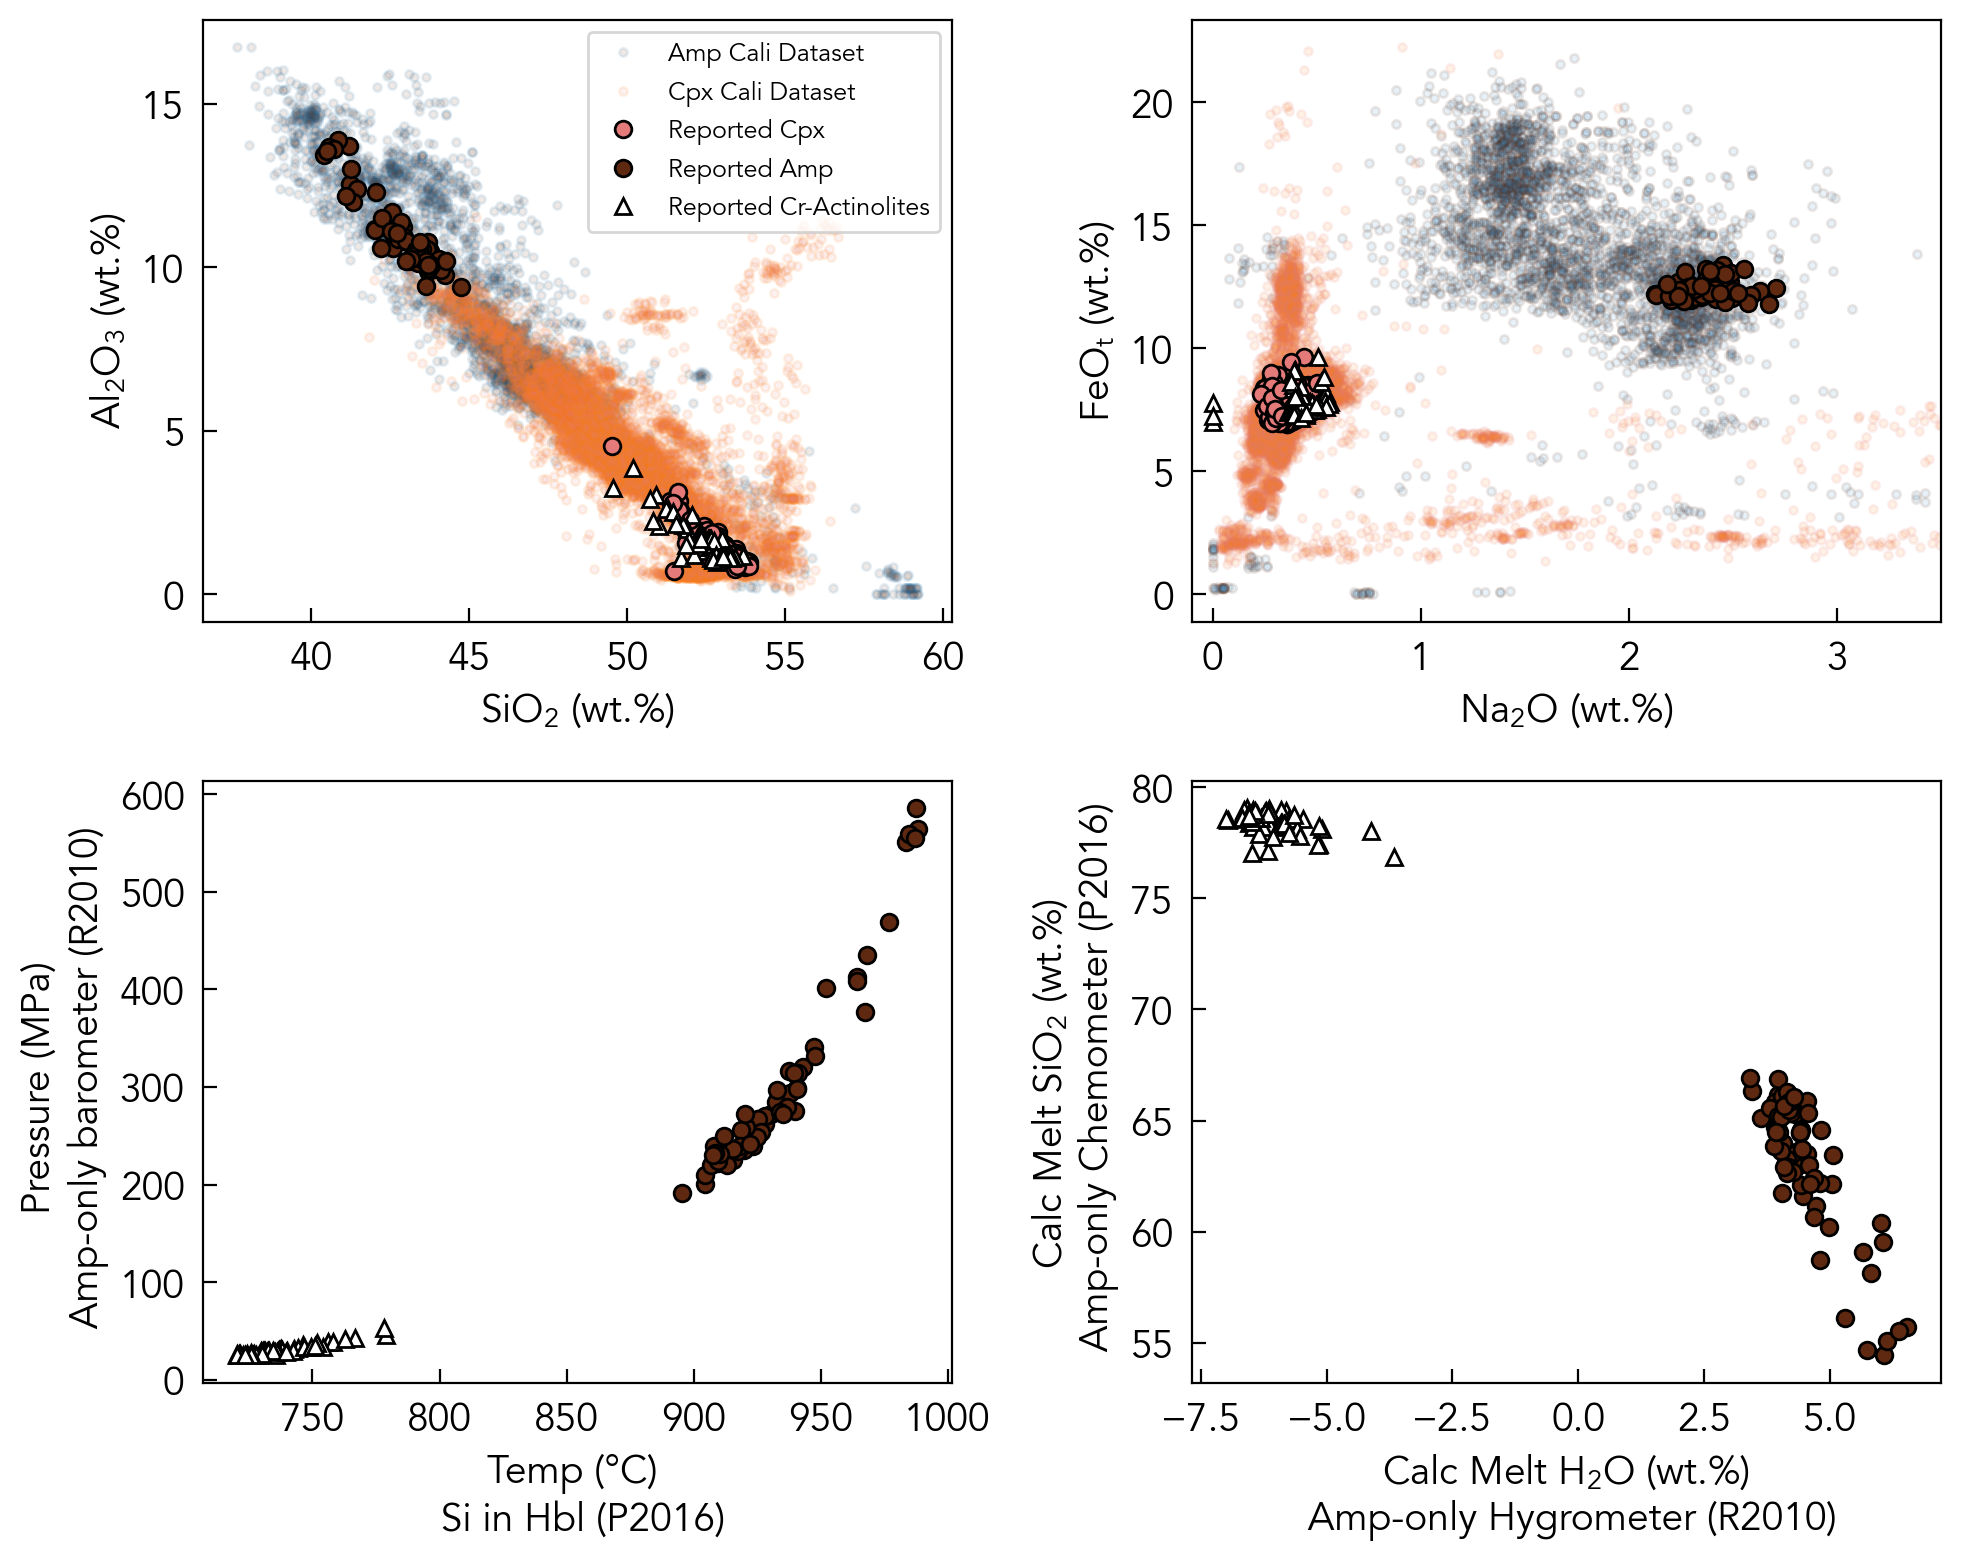

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize = (10,8))
ax1.plot(Test['SiO2'][Test['Mineral']=='Amphibole'], Test['Al2O3'][Test['Mineral']=='Amphibole'], '.', mfc=bii_cols['Amphibole'], 
         alpha=0.1, label='Amp Cali Dataset')
ax1.plot(Test['SiO2'][Test['Mineral']=='Clinopyroxene'], Test['Al2O3'][Test['Mineral']=='Clinopyroxene'], '.',
         mfc=bii_cols['Clinopyroxene'], alpha=0.1, label='Cpx Cali Dataset')
# Plot their data. 
ax1.plot(df_TC_Px['SiO2'], df_TC_Px['Al2O3'], 'ok', mfc=bii_cols['Clinopyroxene'],  label='Reported Cpx')
ax1.plot(df_TC_Amp['SiO2'][~Act], df_TC_Amp['Al2O3'][~Act], 'ok', mfc=bii_cols['Amphibole'], label='Reported Amp')
ax1.plot(df_TC_Amp['SiO2'][Act], df_TC_Amp['Al2O3'][Act], '^k', mfc='white', label='Reported Cr-Actinolites')
#ax1.legend()
ax1.set_xlabel('SiO$\mathregular{_2}$ (wt.%)')
ax1.set_ylabel('Al$\mathregular{_2}$O$\mathregular{_3}$ (wt.%)')
ax1.legend(fontsize=9)

ax2.plot(Test['Na2O'][Test['Mineral']=='Amphibole'], Test['FeOt'][Test['Mineral']=='Amphibole'], '.',
         mec=bii_cols['Amphibole'], alpha=0.1)
ax2.plot(Test['Na2O'][Test['Mineral']=='Clinopyroxene'], Test['FeOt'][Test['Mineral']=='Clinopyroxene'], '.',
          mec=bii_cols['Clinopyroxene'], alpha=0.1)
# Plot their data. 
ax2.plot(df_TC_Px['Na2O'], df_TC_Px['FeO'], 'ok', mfc=bii_cols['Clinopyroxene'], label='Pyroxene')
ax2.plot(df_TC_Amp['Na2O'][~Act], df_TC_Amp['FeO'][~Act], 'ok', mfc=bii_cols['Amphibole'], label='Amphibole')
ax2.plot(df_TC_Amp['Na2O'][Act], df_TC_Amp['FeO'][Act], '^k', mfc='white', label='Cr-Actinolites')

ax2.set_xlabel('Na$\mathregular{_2}$O (wt.%)')
ax2.set_ylabel('FeO$\mathregular{_t}$ (wt.%)')
ax2.set_xlim([-0.1, 3.5])

## Now plotting up thermobarometry results
ax3.plot(df_TC_Amp['[TP16SiinHbl(oC)a'][~Act], df_TC_Amp['PR10(MPa)a'][~Act], 'ok', mfc=bii_cols['Amphibole'], label='Amphibole')
ax3.plot(df_TC_Amp['[TP16SiinHbl(oC)a'][Act], df_TC_Amp['PR10(MPa)a'][Act], '^k', mfc='white', label='Cr-Actinolites')
ax3.set_xlabel('Temp (°C) \n Si in Hbl (P2016)')
ax3.set_ylabel('Pressure (MPa) \n Amp-only Barometer (R2010)')

## Now plotting up thermobarometry results
ax4.plot(df_TC_Amp['H2OmeltR10(%)a'][~Act], df_TC_Amp['SiO2(wt%)a-l]'][~Act], 'ok', mfc=bii_cols['Amphibole'], label='Amphibole')
ax4.plot(df_TC_Amp['H2OmeltR10(%)a'][Act], df_TC_Amp['SiO2(wt%)a-l]'][Act], '^k', mfc='white', label='Cr-Actinolites')
ax4.set_xlabel('Calc Melt $\mathregular{H_2O}$ (wt.%) \n Amp-only Hygrometer (R2010)')
ax4.set_ylabel('Calc Melt $\mathregular{SiO_2}$ (wt.%) \n Amp-only Chemometer (P2016)')
fig.tight_layout()
fig.savefig('OrozcoIssues.pdf', dpi=600)


## Latent space Yamasaki

In [ ]:
cit='[26317] YAMASAKI T. (2022)'
cm = pd.crosstab(
    GEOROC['Mineral'].loc[GEOROC['Citation']==cit],
    GEOROC['Predict_Mineral'].loc[GEOROC['Citation']==cit]
)

cm_percent = cm.div(cm.sum(axis=1), axis=0) * 100

cm.round(2)
display(cm)

Yam_Amp=GEOROC.loc[(GEOROC['Citation']==cit) & (GEOROC['Mineral']=='Amphibole')]

Predict_Mineral,Amphibole,Biotite,Feldspar_Miscibility_Gap,KFeldspar,Plagioclase
Mineral,,,,,
Amphibole,78,35,0,0,29
Biotite,0,12,0,0,0
Feldspar,0,0,1,2,29
Mica,0,24,0,0,0


In [ ]:
cit='[5952] PARMAN S. W. (2003)'
cm = pd.crosstab(
    GEOROC['Mineral'].loc[GEOROC['Citation']==cit],
    GEOROC['Predict_Mineral'].loc[GEOROC['Citation']==cit]
)

cm_percent = cm.div(cm.sum(axis=1), axis=0) * 100

cm.round(2)
display(cm)


Predict_Mineral,Amphibole,Clinopyroxene,Serpentine
Mineral,,,
Amphibole,2,30,4
Pyroxene,1,2,0


In [ ]:
help(mm.plot_z2_overlay)

Help on function plot_z2_overlay in module mineralML.hybrid:

plot_z2_overlay(df, label_column='Predict_Mineral', title='Latent Space (z2) Overlay', ref_kws=None, new_kws=None, max_points=250000, filename=None)
    Plots a 2D latent space overlaying new data on top of reference (training) data.

    This function loads pre-computed training latents as a background reference and
    plots the provided dataframe samples as a foreground overlay. It supports
    custom styling for both layers and handles up to 40 distinct classes using a
    combined 'tab20' and 'tab20b' colormap.

    Parameters
    ----------
    df : pandas.DataFrame
        The input data to be projected into the latent space.
    label_column : str, default="Predict_Mineral"
        The column name in `df` representing the pre-computed labels.
    title : str, default="Latent Space (z2) Overlay"
        The title displayed at the top of the plot.
    ref_kws : dict, optional
        Keyword arguments passed to `ax.sca

c:\Users\penny\anaconda3\Lib\site-packages\mineralML\hybrid.py:1659: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Zr[mask, 0], Zr[mask, 1], color=color, **ref_kws)


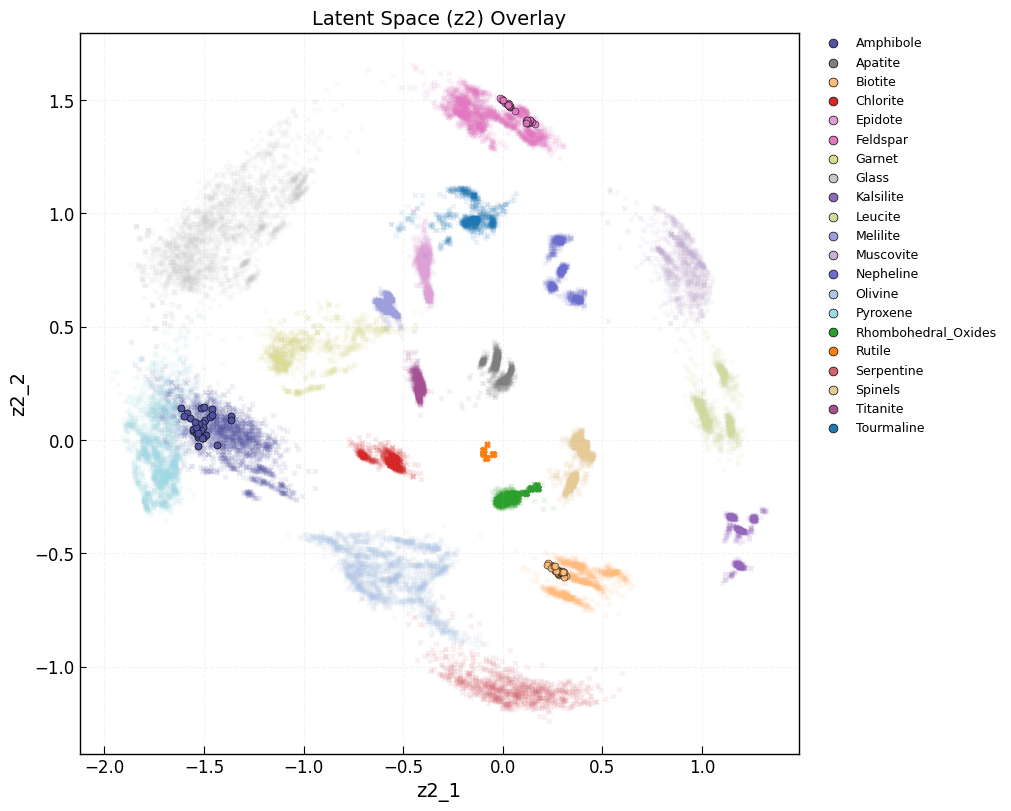

In [ ]:
Yam_All=GEOROC.loc[(GEOROC['Citation']=='[26317] YAMASAKI T. (2022)')] 
fig=mm.plot_z2_overlay(Yam_Amp)


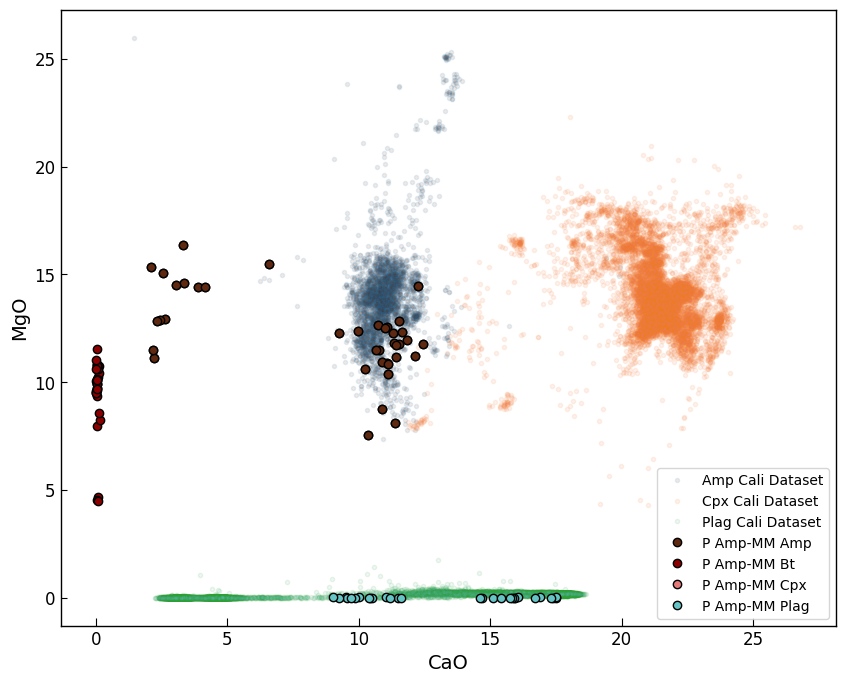

In [ ]:
x='CaO'
y='MgO'
fig, (ax1) = plt.subplots(1, 1, figsize = (10,8))
ax1.plot(Test[x][Test['Mineral']=='Amphibole'], Test[y][Test['Mineral']=='Amphibole'], '.', mfc=bii_cols['Amphibole'], 
         alpha=0.1, label='Amp Cali Dataset')
ax1.plot(Test[x][Test['Mineral']=='Clinopyroxene'], Test[y][Test['Mineral']=='Clinopyroxene'], '.',
         mfc=bii_cols['Clinopyroxene'], alpha=0.1, label='Cpx Cali Dataset')

ax1.plot(Test[x][Test['Mineral']=='Plagioclase'], Test[y][Test['Mineral']=='Plagioclase'], '.',
         mfc=bii_cols['Plagioclase'], alpha=0.1, label='Plag Cali Dataset')

# ax1.plot(Test[x][Test['Mineral']=='Biotite'], Test[y][Test['Mineral']=='Biotite'], '.',
#          mfc='darkred', alpha=0.1, label='Bt Cali Dataset')
# Plot their data. 
YAmp=Yam_Amp['Predict_Mineral']=='Amphibole'
YBt=Yam_Amp['Predict_Mineral']=='Biotite'
YCpx=Yam_Amp['Predict_Mineral']=='Clinopyroxene'
YPlag=Yam_Amp['Predict_Mineral']=='Plagioclase'
ax1.plot(Yam_Amp[x][YAmp], Yam_Amp[y][YAmp], 'ok', mfc=bii_cols['Amphibole'],  label='P Amp-MM Amp')
ax1.plot(Yam_Amp[x][YBt], Yam_Amp[y][YBt], 'ok', mfc='darkred', label='P Amp-MM Bt')
ax1.plot(Yam_Amp[x][YCpx], Yam_Amp[y][YCpx], 'ok', mfc=bii_cols['Clinopyroxene'], label='P Amp-MM Cpx')
ax1.plot(Yam_Amp[x][YPlag], Yam_Amp[y][YPlag], 'ok', mfc=bii_cols['Plagioclase'], label='P Amp-MM Plag')
#ax1.legend()
ax1.set_xlabel(x)
ax1.set_ylabel(y)
ax1.legend(fontsize=10)

In [ ]:
px_class = mm.PyroxeneClassifier(Yam_Amp[YCpx])
px_comp = px_class.calculate_components()
display(px_comp.head())
fig, ax = px_class.plot()

KeyError: "None of [Index(['SiO2_ox', 'TiO2_ox', 'Al2O3_ox', 'FeOt_ox', 'MnO_ox', 'MgO_ox',\n       'CaO_ox', 'Na2O_ox', 'K2O_ox', 'P2O5_ox', 'Cr2O3_ox'],\n      dtype='object')] are in the [columns]"

In [ ]:
Yam_Amp[YCpx].to_clipboard(excel=True)

## Lets show it in one oxide space. 